# QF 627 Programming and Computational Finance
## Lesson 06 | Supervised Machine Learning for Predicting Stock Returns

> Hi Team 👋

> The cross-disciplinary field of quantitative and computational finance is not something that can be mastered simply by reading books or following random programming tutorials. The most effective approach is learning by doing, supported by systematic guidance and real-world case studies. This hands-on method is one of the best ways to develop both understanding and expertise in computational finance.

> Today, we’ll begin exploring machine learning through supervised learning for empirical asset pricing. As a practical example, we’ll work on predicting Microsoft’s stock price.

## DEPENDENCIES

In [1]:
# Load libraries.

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

import seaborn as sns

import time

import datetime as dt
import re

# import plotly.express as px

import pandas_datareader.data as web
from pandas_datareader import data as pdr

import yfinance as yf

import warnings
warnings.filterwarnings("ignore")

# Setting baseline seed
np.random.seed(2025)

# Set print options.

np.set_printoptions(precision = 3)

plt.style.use("ggplot") # Grammar of Graphics Theme

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

%matplotlib inline

In [2]:
yf.__version__

'0.2.65'

In [3]:
%whos

Variable   Type      Data/Info
------------------------------
dt         module    <module 'datetime' from '<...>/python3.12/datetime.py'>
mpl        module    <module 'matplotlib' from<...>/matplotlib/__init__.py'>
np         module    Shape: <function shape at 0x110c00fe0>
pd         module    <module 'pandas' from '/U<...>ages/pandas/__init__.py'>
pdr        module    <module 'pandas_datareade<...>ndas_datareader/data.py'>
plt        module    <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
re         module    <module 're' from '/Libra<...>thon3.12/re/__init__.py'>
sns        module    <module 'seaborn' from '/<...>ges/seaborn/__init__.py'>
time       module    <module 'time' (built-in)>
warnings   module    <module 'warnings' from '<...>/python3.12/warnings.py'>
web        module    <module 'pandas_datareade<...>ndas_datareader/data.py'>
yf         module    <module 'yfinance' from '<...>es/yfinance/__init__.py'>


## 👉 <a id = "top">Learning Pointers</a> 👈 

## [1. Problem Statement and Dependencies for Supervised ML](#p1)

> ### <font color = red> Define and Import </font>

## [2. Wrangle & Prepare Input Features](#p2)

> ### <font color = red> Feature Engineering </font>

## [3. Supervised Machine Learning: Step-by-Step](#p3)

> ### <font color = red> There are five steps </font>

## [4. A First Look at Hyperparameter Tuning](#p4)

> ### <font color = red> Tune `p`,`d`,`q` in ARIMA </font>

## [5. What We Have Learned Thus Far...](#p5)

> ### <font color = red> Supervised Learning for Price Prediction </font>


## <a id = "p1">1. </a> <font color = "green"> Problem Statement & Dependencies for Supervised ML </font>  [back to table of contents](#top)

> We will create a predictive model for the weekly return of MSFT stock. 

> To solve the problem, it is essential to understand what affects Microsoft’s stock price and to incorporate as much information as we can into the model. 

> Among correlated assets, technical indicators, and fundamental analysis, we will concentrate on correlated assets as features here.

### Activate Necessary Packages

> For the supervised regression models

In [4]:
# Step 3: Model Specification

In [5]:
# Let's import our built-in algorithms from scipy toolkit for machine learning

# Oldies But Goodies...

from sklearn.linear_model import LinearRegression # Least Squares

from sklearn.svm import SVR # Support Vector Machine

from sklearn.neighbors import KNeighborsRegressor # K-Nearest Neighbors

# Regularization (Penalized Regressors) --> Linear

from sklearn.linear_model import ElasticNet # Elastic Net Penalty
from sklearn.linear_model import Lasso # LASSO

# Decision Tree with Ensemble --> Non-linear

from sklearn.tree import DecisionTreeRegressor # Decision Tree

## Bagging (Bootstrapped-AGGregation) --> intelligent architecture like Homo Sapiens

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor

## Boosting (more recent approaches) --> Homo Sapiens Sapiens

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor

In [6]:
## Neural Network (with less computational constraints)

## Multi-layer Perceptron

from sklearn.neural_network import MLPRegressor

In [7]:
# %whos

> For data analysis and model evaluation

# 5 steps of model-centric supervised learning
step1: Data split

step2: Feature Engineering 5 + 3

1. proprocessing. check zero variance
2. normalisation (sigma =0, variance = 1)
3. transformation 
    - log, qrt, inverst, yeo johnsong, box-cox
4. encoding
5. imputation
---

1. feature development (massaging X features)
2. feature extraction (signal extraction, dimension reduction)
3. feature selection (pruning features with automated selection - RFE > recursive feature elimination)

In [8]:
### Step 1. Data Split

from sklearn.model_selection import train_test_split

In [9]:
### Step 2. Feature Engineering (Big 5 + 3)

from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression
from sklearn.feature_selection import chi2

In [10]:
### Step 4. Hyper-parameter Tuning

from sklearn.model_selection import cross_val_score, KFold, GridSearchCV

> For time-series models for `machine learning`

In [11]:
import statsmodels.tsa.arima.model as stats

In [12]:
from statsmodels.graphics.tsaplots import plot_acf

> For data preparation and visualization

In [13]:
from pandas.plotting import scatter_matrix

### IMPORT Data

> shift + ctrl + `-` split the given cell

> In addition to historical data on Microsoft, the independent variables used are the following potentially correlated assets.

- Stocks
IBM (IBM) and Alphabet (GOOGL)

In [14]:
stock_ticker = ["MSFT", "IBM", "GOOGL"]

In [15]:
stock_data =\
(
    yf
    .download(stock_ticker, start = "2020-10-15")
    ["Close"]
)

[*********************100%***********************]  3 of 3 completed


In [16]:
stock_data.tail()

Ticker,GOOGL,IBM,MSFT
Date,,,
2025-10-07,245.759995,293.869995,523.979980
2025-10-08,244.619995,289.459991,524.849976
2025-10-09,241.529999,288.230011,522.400024
2025-10-10,236.570007,277.820007,510.959991
2025-10-13,244.149994,277.220001,514.049988


- Currency
USD/JPY and GBP/USD

In [17]:
forex_ticker = ["DEXJPUS", "DEXUSUK"]

In [18]:
forex_data =\
(
    pdr
    .get_data_fred(forex_ticker, start = "2020-10-15")
)

In [19]:
forex_data.shape

(1297, 2)

- Indices
S&P 500, Dow Jones, and VIX

In [20]:
index_ticker = ["SP500", "DJIA", "VIXCLS"]

In [21]:
index_data =\
(
    pdr
    .get_data_fred(index_ticker)
)

In [22]:
index_data

,SP500,DJIA,VIXCLS
DATE,,,
2020-10-15,3483.34,28494.20,26.97
2020-10-16,3483.81,28606.31,27.41
2020-10-19,3426.92,28195.42,29.18
2020-10-20,3443.12,28308.79,29.35
2020-10-21,3435.56,28210.82,28.65
...,...,...,...
2025-10-07,6714.59,46602.98,17.24
2025-10-08,NaN,46601.78,16.30
2025-10-09,NaN,46358.42,16.43


In [23]:
# %whos

## <a id = "p2">2. </a> <font color = "green"> Wrangle and Prepare Input Features </font>  [back to table of contents](#top)

### Data Transformation

> Next, we define our outcome (Y) and predictor (X) variables. The outcome variable is the weekly return of MSFT. The predicted variable is the weekly return of Microsoft (MSFT). 

> The number of trading days in a week is assumed to be five, and we compute the return using five trading days. For predictor variables we use the correlated assets and the historical return of MSFT at different frequencies.

> The variables used as predictors are lagged five-day returns of stocks (IBM and GOOG), currency exchange rates (USD/JPY and GBP/USD), and indices (S&P 500, Dow Jones, and VIX), along with lagged five-day, 15-day, 30-day, and 60-day returns of MSFT.

> The lagged five-day variables embed the time series component by using a time-delay approach, where the lagged variable is included as one of the predictor variables. This step translates the time series data into a supervised regression-based model framework.

### Outcome (Y): Lograthimc Returns of 5-day MSFT

In [24]:
return_period = 5

In [25]:
stock_data

Ticker,GOOGL,IBM,MSFT
Date,,,
2020-10-15,77.240768,96.214195,210.615540
2020-10-16,77.848076,97.015404,210.615540
2020-10-19,75.973495,96.699554,205.399582
2020-10-20,77.022766,90.420868,205.811859
2020-10-21,78.756302,88.641251,205.955704
...,...,...,...
2025-10-07,245.759995,293.869995,523.979980
2025-10-08,244.619995,289.459991,524.849976
2025-10-09,241.529999,288.230011,522.400024


In [26]:
stock_data.loc[ : , "MSFT"]

Date
2020-10-15    210.615540
2020-10-16    210.615540
2020-10-19    205.399582
2020-10-20    205.811859
2020-10-21    205.955704
                 ...    
2025-10-07    523.979980
2025-10-08    524.849976
2025-10-09    522.400024
2025-10-10    510.959991
2025-10-13    514.049988
Name: MSFT, Length: 1254, dtype: float64

In [27]:
stock_data.loc[ : , "MSFT"].tail(5)

Date
2025-10-07    523.979980
2025-10-08    524.849976
2025-10-09    522.400024
2025-10-10    510.959991
2025-10-13    514.049988
Name: MSFT, dtype: float64

In [28]:
stock_data.loc[ : , "MSFT"].tail(5).shift(1)

Date
2025-10-07           NaN
2025-10-08    523.979980
2025-10-09    524.849976
2025-10-10    522.400024
2025-10-13    510.959991
Name: MSFT, dtype: float64

In [29]:
Y =\
(
    np
    .log(stock_data.loc[ : , "MSFT"] # log return of MSFT
        )
    .diff(return_period)
    .shift(-return_period)
)

Y

Date
2020-10-15   -0.021954
2020-10-16   -0.015738
2020-10-19   -0.019515
2020-10-20   -0.006544
2020-10-21   -0.058079
                ...   
2025-10-07         NaN
2025-10-08         NaN
2025-10-09         NaN
2025-10-10         NaN
2025-10-13         NaN
Name: MSFT, Length: 1254, dtype: float64

In [30]:
Y.name

'MSFT'

In [31]:
Y.name =\
(
    Y
    .name
    + 
    "_pred"
)

In [32]:
Y

Date
2020-10-15   -0.021954
2020-10-16   -0.015738
2020-10-19   -0.019515
2020-10-20   -0.006544
2020-10-21   -0.058079
                ...   
2025-10-07         NaN
2025-10-08         NaN
2025-10-09         NaN
2025-10-10         NaN
2025-10-13         NaN
Name: MSFT_pred, Length: 1254, dtype: float64

### Input Features (Xs)

In [33]:
return_period

5

In [34]:
X1 =\
(
    np
    .log(stock_data.loc[ : , ("IBM", "GOOGL")]
        )
    .diff(return_period)
)

X1

Ticker,IBM,GOOGL
Date,,
2020-10-15,NaN,NaN
2020-10-16,NaN,NaN
2020-10-19,NaN,NaN
2020-10-20,NaN,NaN
2020-10-21,NaN,NaN
...,...,...
2025-10-07,0.040663,0.010883
2025-10-08,0.010313,-0.001144
2025-10-09,0.005253,-0.017077


In [35]:
X2 =\
(
    np
    .log(forex_data)
    .diff(return_period)
)

X2.head(6)

,DEXJPUS,DEXUSUK
DATE,,
2020-10-15,NaN,NaN
2020-10-16,NaN,NaN
2020-10-19,NaN,NaN
2020-10-20,NaN,NaN
2020-10-21,NaN,NaN
2020-10-22,-0.004756,0.013304


In [36]:
X3 =\
(
    np
    .log(index_data)
    .diff(return_period)
)

In [37]:
X3.head(6)

,SP500,DJIA,VIXCLS
DATE,,,
2020-10-15,NaN,NaN,NaN
2020-10-16,NaN,NaN,NaN
2020-10-19,NaN,NaN,NaN
2020-10-20,NaN,NaN,NaN
2020-10-21,NaN,NaN,NaN
2020-10-22,-0.008606,-0.004592,0.0414


In [38]:
Y.head(6)

Date
2020-10-15   -0.021954
2020-10-16   -0.015738
2020-10-19   -0.019515
2020-10-20   -0.006544
2020-10-21   -0.058079
2020-10-22   -0.048483
Name: MSFT_pred, dtype: float64

> Team, FYI, after the logarithmic transformation, 
> the .diff(return_period) function is called on the resulting DataFrame. 

> This calculates the difference of consecutive log values (log-return) with a specified lag equal to return_period. 

> The return_period is a parameter representing the number of periods (rows) over which the difference is calculated.

In [39]:
X4 =\
pd.concat(
    [np
    .log(stock_data.loc[ : , "MSFT"]
        )
    .diff(i) for i in [return_period,
                       return_period * 3, # 15
                       return_period * 6, # 30
                       return_period * 12 # 60
                      ]
    ],
    axis = 1
)

In [40]:
X4.columns = ["MSFT_DT", "MSFT_3DT", "MSFT_6DT", "MSFT_12DT"]

In [41]:
X4.isnull().sum()

MSFT_DT       5
MSFT_3DT     15
MSFT_6DT     30
MSFT_12DT    60
dtype: int64

In [42]:
index_data

,SP500,DJIA,VIXCLS
DATE,,,
2020-10-15,3483.34,28494.20,26.97
2020-10-16,3483.81,28606.31,27.41
2020-10-19,3426.92,28195.42,29.18
2020-10-20,3443.12,28308.79,29.35
2020-10-21,3435.56,28210.82,28.65
...,...,...,...
2025-10-07,6714.59,46602.98,17.24
2025-10-08,NaN,46601.78,16.30
2025-10-09,NaN,46358.42,16.43


In [43]:
stock_data.shape, forex_data.shape, index_data.shape, Y.shape, X1.shape, X2.shape, X3.shape, X4.shape

((1254, 3),
 (1297, 2),
 (1303, 3),
 (1254,),
 (1254, 2),
 (1297, 2),
 (1303, 3),
 (1254, 4))

> For each value i in the list [return_period, return_period * 3, return_period * 6, return_period * 12], 
> let's calculates the logarithm of the values in column ("Adj Close", "MSFT") 
> of DataFrame stock_data, 
> and then calculates the difference of consecutive log values (log-return) with lag i. 

> This results in a list of DataFrames.


> The DataFrames from the list comprehension are concatenated along the columns (axis=1),
> creating a single DataFrame. 

> After concatenation, rows containing any NaN values are dropped using .dropna().

In [44]:
# all the input features 

X =\
(
    pd
    .concat([X1, X2, X3, X4],
            axis = 1)
)

X

,IBM,GOOGL,DEXJPUS,DEXUSUK,SP500,DJIA,VIXCLS,MSFT_DT,MSFT_3DT,MSFT_6DT,MSFT_12DT
2020-10-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2025-10-07,0.040663,0.010883,NaN,NaN,0.003899,0.004411,0.057295,0.011575,0.028927,0.038361,0.042466
2025-10-08,0.010313,-0.001144,NaN,NaN,NaN,0.003454,0.000614,0.009841,0.028663,0.044433,0.038574
2025-10-09,0.005253,-0.017077,NaN,NaN,NaN,-0.003473,-0.012099,0.012831,0.027067,0.030436,0.034291
2025-10-10,-0.037271,-0.036442,NaN,NaN,NaN,-0.027727,0.263057,-0.012428,-0.013549,0.002587,0.000195


In [45]:
X.isnull().sum()

IBM           54
GOOGL         54
DEXJPUS      118
DEXUSUK      118
SP500        103
DJIA          99
VIXCLS        48
MSFT_DT       54
MSFT_3DT      64
MSFT_6DT      79
MSFT_12DT    109
dtype: int64

In [46]:
X.columns

Index(['IBM', 'GOOGL', 'DEXJPUS', 'DEXUSUK', 'SP500', 'DJIA', 'VIXCLS',
       'MSFT_DT', 'MSFT_3DT', 'MSFT_6DT', 'MSFT_12DT'],
      dtype='object')

> Let's concatenate two DataFrames Y and X along the columns, 
> dropping any rows with missing values, 
> and then selecting rows 
> at regular intervals specified by return_period. 

In [47]:
data =\
(
    pd
    .concat([Y, X],
            axis = 1)
    .dropna()
)

In [48]:
data.shape

(1126, 12)

In [49]:
data.iloc[ : :return_period, : ].shape

(226, 12)

In [50]:
data =\
(
    data
    .iloc[ : :return_period, : ]
)

In [51]:
data

,MSFT_pred,IBM,GOOGL,DEXJPUS,DEXUSUK,SP500,DJIA,VIXCLS,MSFT_DT,MSFT_3DT,MSFT_6DT,MSFT_12DT
2021-01-12,0.042850,0.024047,-0.001507,0.013444,0.001247,0.019748,0.022034,-0.082644,-0.013724,-0.016885,-0.001395,-0.019154
2021-01-21,0.060204,0.036590,0.075433,-0.000869,0.002262,0.015044,0.005935,-0.086660,0.039116,0.003651,0.048637,0.042239
2021-02-01,0.011699,0.016394,-0.000639,0.011401,0.000293,-0.021366,-0.024460,0.265444,0.043146,0.087281,0.088830,0.151833
2021-02-08,0.005060,0.025150,0.096339,0.002094,0.004816,0.036868,0.038118,-0.353279,0.011699,0.131230,0.092625,0.141587
2021-02-16,-0.041441,-0.015782,0.012481,0.011972,0.008229,0.005446,0.004672,-0.007891,0.005060,0.059904,0.091370,0.130429
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-04,-0.013796,0.009512,0.112995,0.011163,-0.005564,0.000034,-0.000342,0.058543,0.002424,-0.022879,0.005785,0.073498
2025-09-12,0.015625,0.019564,0.025275,0.006855,0.000295,0.015735,0.009500,-0.028058,0.029657,0.011162,-0.043602,0.066163
2025-09-19,-0.012571,0.049872,0.056198,-0.000135,-0.004661,0.012087,0.010441,0.045688,0.015625,0.016135,-0.003960,0.052455
2025-09-26,0.011450,0.065066,-0.032641,0.011367,-0.005951,-0.003105,-0.001469,-0.010410,-0.012571,0.032712,-0.019675,0.042284


In [52]:
Y =\
(
    data
    .loc[ : , Y.name]
)

Y

2021-01-12    0.042850
2021-01-21    0.060204
2021-02-01    0.011699
2021-02-08    0.005060
2021-02-16   -0.041441
                ...   
2025-09-04   -0.013796
2025-09-12    0.015625
2025-09-19   -0.012571
2025-09-26    0.011450
2025-10-03   -0.012428
Name: MSFT_pred, Length: 226, dtype: float64

In [53]:
X.columns

Index(['IBM', 'GOOGL', 'DEXJPUS', 'DEXUSUK', 'SP500', 'DJIA', 'VIXCLS',
       'MSFT_DT', 'MSFT_3DT', 'MSFT_6DT', 'MSFT_12DT'],
      dtype='object')

In [54]:
X =\
(
    data
    .loc[ : , X.columns]
)

In [55]:
X

,IBM,GOOGL,DEXJPUS,DEXUSUK,SP500,DJIA,VIXCLS,MSFT_DT,MSFT_3DT,MSFT_6DT,MSFT_12DT
2021-01-12,0.024047,-0.001507,0.013444,0.001247,0.019748,0.022034,-0.082644,-0.013724,-0.016885,-0.001395,-0.019154
2021-01-21,0.036590,0.075433,-0.000869,0.002262,0.015044,0.005935,-0.086660,0.039116,0.003651,0.048637,0.042239
2021-02-01,0.016394,-0.000639,0.011401,0.000293,-0.021366,-0.024460,0.265444,0.043146,0.087281,0.088830,0.151833
2021-02-08,0.025150,0.096339,0.002094,0.004816,0.036868,0.038118,-0.353279,0.011699,0.131230,0.092625,0.141587
2021-02-16,-0.015782,0.012481,0.011972,0.008229,0.005446,0.004672,-0.007891,0.005060,0.059904,0.091370,0.130429
...,...,...,...,...,...,...,...,...,...,...,...
2025-09-04,0.009512,0.112995,0.011163,-0.005564,0.000034,-0.000342,0.058543,0.002424,-0.022879,0.005785,0.073498
2025-09-12,0.019564,0.025275,0.006855,0.000295,0.015735,0.009500,-0.028058,0.029657,0.011162,-0.043602,0.066163
2025-09-19,0.049872,0.056198,-0.000135,-0.004661,0.012087,0.010441,0.045688,0.015625,0.016135,-0.003960,0.052455
2025-09-26,0.065066,-0.032641,0.011367,-0.005951,-0.003105,-0.001469,-0.010410,-0.012571,0.032712,-0.019675,0.042284


### Exploratory Data Analysis (EDA)

In [56]:
correlation =\
(
    data
    .corr()
)

<Axes: >

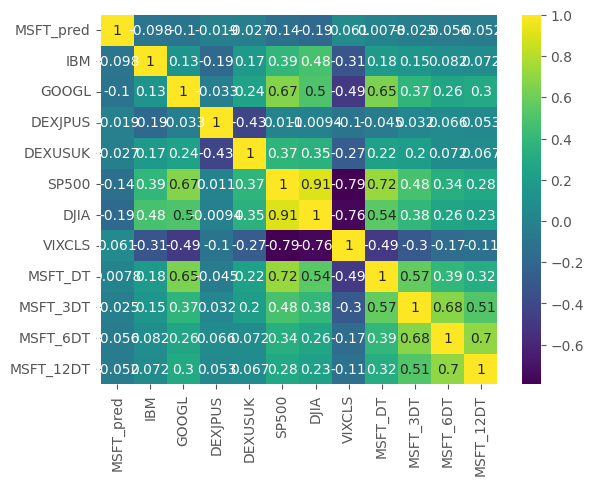

In [57]:
(
    sns
    .heatmap(correlation,
             cmap = "viridis",
             annot = True)
)

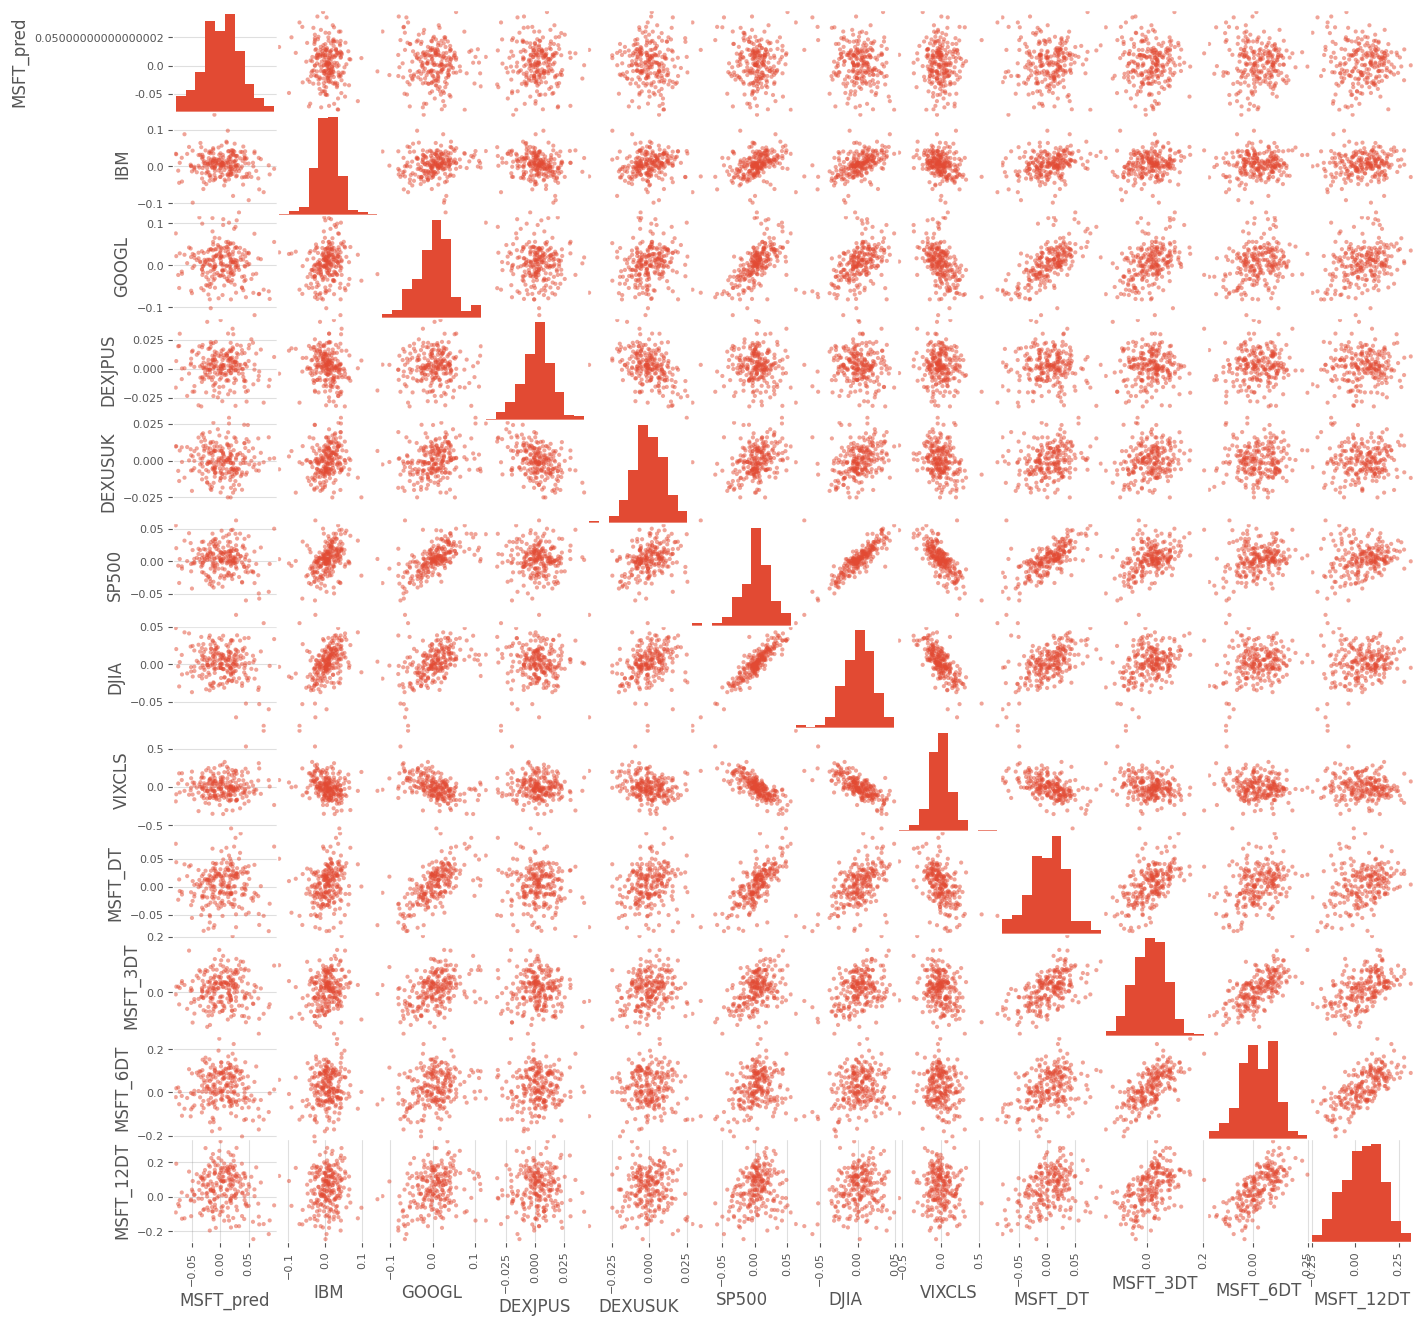

In [58]:
scatter_matrix(data,
               figsize = [16,16]
              )

plt.show()

## <a id = "p3">3. </a> <font color = "green"> Supervised Machine Learning: A Step-by-Step Guide </font>  [back to table of contents](#top)

### Step 1: Data Split

> Let's partition the original dataset into a training set and a test set.

In [59]:
len(X)

226

In [60]:
testing_set = 0.20

train_size = int(len(X) * (1 - testing_set)
                )

In [61]:
train_size

180

In [62]:
len(Y) == len(X) # cross-validate the data

True

In [63]:
# Outcome Split

In [64]:
Y_train, Y_test =\
(
    Y[0         : train_size],
    Y[train_size:len(Y)     ]
)

In [65]:
# Input Features (Predictors) Split

In [66]:
X_train, X_test =\
(
    X[0         : train_size],
    X[train_size:len(X)     ]
)

In [67]:
len(X_train) 

180

In [68]:
len(X_test)

46

In [69]:
len(X)

226

### Preprations for Step 4: Ten-fold Cross Validation and Evaluation Metrics

In [70]:
seed = 2025
num_folds = 10

metric = "neg_mean_squared_error"

### Step 3: Fitting: Model Comparison with ML Algorithms

In [71]:
models = [] # staging

In [72]:
sample_list = ["M", "Q", "F"]

In [73]:
sample_list.append("627")

In [74]:
sample_list

['M', 'Q', 'F', '627']

#### Regression and tree regression algorithms

# Least Squares

In [75]:
(
    models
    .append(
        ("LR", LinearRegression()
         )
           )
)

# Regularization Algorithms 

In [76]:
(
    models
    .append(
        ("LASSO", Lasso()
         )
           )
)

(
    models
    .append(
        ("Elastic Net Penalty", ElasticNet()
         )
           )
)

# Decision Tree (Greedy Algorithm)

In [77]:
(
    models
    .append(
        ("Decision Tree", DecisionTreeRegressor()
         )
           )
)

# Ensemble models

In [78]:
## Bagging 

(
    models
    .append(
        ("Random Forest", RandomForestRegressor()
         )
           )
)

(
    models
    .append(
        ("Extra Trees Algo", ExtraTreesRegressor()
         )
           )
)

In [79]:
## Boosting

(
    models
    .append(
        ("Gradient Boosting", GradientBoostingRegressor()
         )
           )
)

(
    models
    .append(
        ("Adaptive Boosting", AdaBoostRegressor()
         )
           )
)

# Oldies But Goodies beyond Least Squares

In [80]:
(
    models
    .append(
        ("Support Vector Machine", SVR()
         )
           )
)

(
    models
    .append(
        ("K-Nearest Neighbors", KNeighborsRegressor()
         )
           )
)

In [81]:
len(models)

10

In [82]:
models

[('LR', LinearRegression()),
 ('LASSO', Lasso()),
 ('Elastic Net Penalty', ElasticNet()),
 ('Decision Tree', DecisionTreeRegressor()),
 ('Random Forest', RandomForestRegressor()),
 ('Extra Trees Algo', ExtraTreesRegressor()),
 ('Gradient Boosting', GradientBoostingRegressor()),
 ('Adaptive Boosting', AdaBoostRegressor()),
 ('Support Vector Machine', SVR()),
 ('K-Nearest Neighbors', KNeighborsRegressor())]

In [83]:
# models.pop(1)

In [84]:
# models

In [85]:
# len(models)

> Once you have selected all the models, you might want to loop over each of them. 

> First, let’s run the k-fold analysis. Then try to run the model on the entire training and testing dataset.

> All the algorithms use default tuning parameters. We will calculate the mean and standard deviation of the evaluation metric for each algorithm, collecting the results for model comparison.

### Best Practice in ML: Compare Algorithms' Performance

In [86]:
# Let's build empty lists to store performance across many algorithms

names = []

train_results = []
test_results = []

kfold_results = []

In [87]:
models

[('LR', LinearRegression()),
 ('LASSO', Lasso()),
 ('Elastic Net Penalty', ElasticNet()),
 ('Decision Tree', DecisionTreeRegressor()),
 ('Random Forest', RandomForestRegressor()),
 ('Extra Trees Algo', ExtraTreesRegressor()),
 ('Gradient Boosting', GradientBoostingRegressor()),
 ('Adaptive Boosting', AdaBoostRegressor()),
 ('Support Vector Machine', SVR()),
 ('K-Nearest Neighbors', KNeighborsRegressor())]

In [88]:
num_folds

10

In [89]:
metric

'neg_mean_squared_error'

In [90]:
from sklearn.metrics import mean_squared_error

In [91]:
for name, model in models:

    names.append(name)

    # set k-fold cross-validation (here, 10)

    kfold =\
    (
        KFold(n_splits = num_folds,
              random_state = seed,
              shuffle = True)
    )

    # run cross-validation

    cv_results =\
    (
        -1
        *
        cross_val_score(model, X_train, Y_train,
                        cv = kfold,
                        scoring = metric)
    )

    # Cross-validation results should be contained in objects

    kfold_results.append(cv_results)

    # Training Set Model Fitting

    res = model.fit(X_train, Y_train)

    # Assess the performance in Training Set

    train_result = mean_squared_error(res.predict(X_train), Y_train)

    train_results.append(train_result)

    # Assess the performance in Testing Set

    test_result = mean_squared_error(res.predict(X_test), Y_test)

    test_results.append(test_result)    

    user_interface_message = "%s: %f (%f) %f %f " % (name, 
                                                     cv_results.mean(), 
                                                     cv_results.std(), 
                                                     train_result, 
                                                     test_result)

    print(user_interface_message)

LR: 0.001094 (0.000431) 0.000940 0.001216 
LASSO: 0.001039 (0.000267) 0.001024 0.001275 
Elastic Net Penalty: 0.001039 (0.000267) 0.001024 0.001275 
Decision Tree: 0.001882 (0.000471) 0.000000 0.001544 
Random Forest: 0.001088 (0.000280) 0.000151 0.001081 
Extra Trees Algo: 0.001061 (0.000251) 0.000000 0.001079 
Gradient Boosting: 0.001277 (0.000291) 0.000118 0.001161 
Adaptive Boosting: 0.001144 (0.000379) 0.000514 0.001295 
Support Vector Machine: 0.001014 (0.000255) 0.001025 0.001277 
K-Nearest Neighbors: 0.001158 (0.000332) 0.000730 0.001160 


#### <mark>Comparing the algorithms by examining the Training vs. Testing Set</mark>

In [92]:
names

['LR',
 'LASSO',
 'Elastic Net Penalty',
 'Decision Tree',
 'Random Forest',
 'Extra Trees Algo',
 'Gradient Boosting',
 'Adaptive Boosting',
 'Support Vector Machine',
 'K-Nearest Neighbors']

In [93]:
names

['LR',
 'LASSO',
 'Elastic Net Penalty',
 'Decision Tree',
 'Random Forest',
 'Extra Trees Algo',
 'Gradient Boosting',
 'Adaptive Boosting',
 'Support Vector Machine',
 'K-Nearest Neighbors']

In [94]:
len(names)

10

In [95]:
names * 2

['LR',
 'LASSO',
 'Elastic Net Penalty',
 'Decision Tree',
 'Random Forest',
 'Extra Trees Algo',
 'Gradient Boosting',
 'Adaptive Boosting',
 'Support Vector Machine',
 'K-Nearest Neighbors',
 'LR',
 'LASSO',
 'Elastic Net Penalty',
 'Decision Tree',
 'Random Forest',
 'Extra Trees Algo',
 'Gradient Boosting',
 'Adaptive Boosting',
 'Support Vector Machine',
 'K-Nearest Neighbors']

In [96]:
len(train_results)

10

In [97]:
len(test_results)

10

In [98]:
df_for_comparison =\
(
    pd
    .DataFrame(
        {"Algorithms": names * 2,
         "Data": ["Training Set"] * len(names) + ["Testing Set"] * len(names),
         "Performance": train_results + test_results
         }
    )
)

In [99]:
df_for_comparison

,Algorithms,Data,Performance
0,LR,Training Set,9.404627e-04
1,LASSO,Training Set,1.024485e-03
2,Elastic Net Penalty,Training Set,1.024485e-03
3,Decision Tree,Training Set,0.000000e+00
4,Random Forest,Training Set,1.511407e-04
5,Extra Trees Algo,Training Set,2.674903e-35
6,Gradient Boosting,Training Set,1.176721e-04
7,Adaptive Boosting,Training Set,5.141586e-04
8,Support Vector Machine,Training Set,1.025440e-03
9,K-Nearest Neighbors,Training Set,7.295291e-04


In [100]:
df_for_comparison.columns

Index(['Algorithms', 'Data', 'Performance'], dtype='object')

In [101]:
from lets_plot import *
LetsPlot.setup_html()

In [102]:
performance_comparison =\
(
    ggplot(df_for_comparison,
           aes(x = "Algorithms",
               y = "Performance",
               fill = "Data"
              )
          )
    + geom_bar(stat = "identity",
               position = "dodge",
               width = 0.5)
    + labs(title = "Comparing the Performance of Machine Learning Algorithms on the Training vs. Testing Set",
           y = "Mean Squared Error (MSE)",
           x = "Name of ML Algorithms",
           caption = "Source: Federal Reserve Bank & Yahoo Finance")
    + theme(legend_position = "top")
    + ggsize(1000, 500)
)

performance_comparison.show()

# Evaluation
> Always look for lower blue bar!!!!!

### Time Series based models (ARIMA)

> Let us first prepare the dataset for ARIMA models, by having only the correlated variables as exogenous variables.

#### ARIMA

In [103]:
X_train.columns

Index(['IBM', 'GOOGL', 'DEXJPUS', 'DEXUSUK', 'SP500', 'DJIA', 'VIXCLS',
       'MSFT_DT', 'MSFT_3DT', 'MSFT_6DT', 'MSFT_12DT'],
      dtype='object')

In [104]:
X_train_ARIMA =\
(
    X_train
    .loc[ : , ['IBM', 'GOOGL', 'DEXJPUS', 'DEXUSUK', 'SP500', 'DJIA', 'VIXCLS']]
)

X_test_ARIMA =\
(
    X_test
    .loc[ : , ['IBM', 'GOOGL', 'DEXJPUS', 'DEXUSUK', 'SP500', 'DJIA', 'VIXCLS']]
)

In [105]:
len(X_train_ARIMA) + len(X_test_ARIMA) == len(X)

True


* `p` denotes the order of Auto Regression (AR) polynomials

* `d` denotes the number of nonseasonal differences needed for stationarity

* `q` denotes the order of Moving Average (MA) polynomials


In [106]:
baseline_ARIMA =\
(
    stats
    .ARIMA(endog = Y_train,
           exog = X_train_ARIMA,
           order = [1, 0, 0]
          )
)

/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [107]:
ARIMA_fitted =\
(
    baseline_ARIMA
    .fit()
)

/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [108]:
error_training_ARIMA =\
(
    mean_squared_error(Y_train, 
                       ARIMA_fitted.fittedvalues)
)

In [109]:
predicted =\
(
    ARIMA_fitted
    .predict(start = len(X_train_ARIMA) - 1,
             end = len(X) - 1,
             exog = X_test_ARIMA
            )[1 : ]
)

/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [110]:
predicted

180    0.008692
181    0.011036
182    0.002653
183    0.005448
184   -0.002447
185    0.002356
186    0.008423
187    0.006469
188    0.010435
189    0.009677
190    0.006012
191   -0.008864
192   -0.004449
193    0.008045
194    0.013399
195    0.011433
196   -0.001664
197    0.015668
198    0.030900
199    0.003063
200    0.010541
201    0.028028
202   -0.021986
203    0.045311
204   -0.010115
205   -0.001707
206   -0.001003
207   -0.003741
208    0.002203
209    0.007442
210   -0.005806
211    0.007363
212   -0.011696
213    0.008021
214    0.001036
215   -0.002167
216    0.007096
217    0.005493
218    0.000674
219    0.001339
220   -0.003378
221   -0.003632
222   -0.001150
223   -0.007073
224    0.008724
225   -0.005431
Name: predicted_mean, dtype: float64

In [111]:
error_testing_ARIMA =\
(
    mean_squared_error(Y_test,
                       predicted)
)

In [112]:
error_training_ARIMA

0.0009547421527140522

In [113]:
error_testing_ARIMA

0.001173142546654398

## <a id = "p4">4. </a> <font color = "green"> An Introduction to Hyperparameter Tuning </font>  [back to table of contents](#top)

### <mark>A Gift</mark> Model Tuning and Grid Search for ARIMA

In [114]:
# Hyperparameter Tuning; Grid Search for ARIMA

def assess_ARIMA_model(arima_order):
    
    modelARIMA = stats.ARIMA(endog = Y_train, 
                             exog = X_train_ARIMA,
                             order = arima_order)
    # Our model takes an arima_order as input, 
    # fits an ARIMA model to the training data Y_train 
    # with exogenous variables X_train_ARIMA, 
    
    model_fit = modelARIMA.fit()
    # and then calculates 

    error = mean_squared_error(Y_train,
                               model_fit.fittedvalues)
    
    # and returns the Mean Squared Error (MSE) 
    # between the true and the fitted values.

    return error

def assess_models(p_values, d_values, q_values):
    
    # Team, our function performs grid search 
    # over all combinations of provided p, d, and q values. 
    
    # For each combination, it calculates the MSE and prints it. 
    
    # If the MSE for the current combination 
    # is less than the best score encountered so far, 
    # it updates the best score and the corresponding configuration. 
    
    # At the end of the grid search, 
    # it prints the best configuration and its MSE.
    
    best_score, best_cfg = float("inf"), None

    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p, d, q)
                try:
                    mse = assess_ARIMA_model(order)
                    if mse < best_score:
                        best_score, best_cfg = mse, order
                    
                    print("ARIMA%s MSE = %.7f" % (order, mse)
                          )
                    
                except:
                    continue
    print("Best ARIMA%s MSE = %.7f" % (best_cfg, best_score)
          )
    
# parameters to use for assessment

# Recall that the ARIMA model 
# is characterized by three parameters: 
# (p, d, q) which stand for the order of autoregression, 
# the degree of differencing, 
# and the order of the moving average, respectively.

p_values = [0, 1, 2]
d_values = range(0, 2)
q_values = range(0, 2)

> Calculate accuracy on testing data

In [115]:
assess_models(p_values,
              d_values,
              q_values)

/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency informatio

ARIMA(0, 0, 0) MSE = 0.0009712
ARIMA(0, 0, 1) MSE = 0.0009568
ARIMA(0, 1, 0) MSE = 0.0014608


/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency informatio

ARIMA(0, 1, 1) MSE = 0.0010180
ARIMA(1, 0, 0) MSE = 0.0009547
ARIMA(1, 0, 1) MSE = 0.0009554


/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored whe

ARIMA(1, 1, 0) MSE = 0.0013425
ARIMA(1, 1, 1) MSE = 0.0010037
ARIMA(2, 0, 0) MSE = 0.0009547


/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

ARIMA(2, 0, 1) MSE = 0.0009552
ARIMA(2, 1, 0) MSE = 0.0012957
ARIMA(2, 1, 1) MSE = 0.0010640
Best ARIMA(2, 0, 0) MSE = 0.0009547


/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [116]:
ARIMA_Tuned =\
(
    stats
    .ARIMA(endog = Y_train,
           exog = X_train_ARIMA,
           order = [2, 0, 0]
          )
)

ARIMA_algo_tuned = ARIMA_Tuned.fit()

/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

In [117]:
predictions_ARIMA_TUNED =\
(
    ARIMA_algo_tuned
    .predict(start = len(X_train_ARIMA) - 1,
             end = len(X) - 1,
             exog = X_test_ARIMA
            )[1 : ]
)

/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


- `model_fit` is a fitted ARIMA model instance.
<br>

- `model_fit.predict()` is used to make predictions based on the fitted model.
<br>

- `start=train_len - 1` specifies the starting point of the prediction. Our code is setting it to one less than the length of the training data.
<br>

- `end=total_len - 1` sets the endpoint of the prediction. It is one less than the total length of the dataset, indicating that predictions will be made for the entire testing set.
<br>

- `exog=X_test_ARIMA` refers to exogenous variables, which are external factors that can influence the predictions. X_test_ARIMA is presumably the testing set of these exogenous variables.
<br>

- `[1:]` is used to exclude the first element from the predicted values. It might be done to align the predicted values with the actual values, especially if the prediction includes the last observation from the training set.

### Use `lets_plot` for ***interactive*** <mark>dashboarding-like</mark> reporting

In [118]:
predictions_ARIMA_TUNED.index = Y_test.index

In [119]:
predictions_ARIMA_TUNED

2024-10-22    0.008699
2024-10-29    0.009123
2024-11-05    0.002292
2024-11-13    0.005177
2024-11-21   -0.000918
2024-11-29    0.001787
2024-12-09    0.008700
2024-12-16    0.006439
2024-12-23    0.010682
2024-12-31    0.010291
2025-01-10    0.006794
2025-01-21   -0.009890
2025-01-29   -0.004181
2025-02-05    0.010758
2025-02-12    0.013469
2025-02-20    0.011886
2025-02-28   -0.002107
2025-03-07    0.016629
2025-03-14    0.030814
2025-03-21    0.002386
2025-03-28    0.011232
2025-04-04    0.029305
2025-04-11   -0.023600
2025-04-21    0.046867
2025-04-29   -0.011827
2025-05-06   -0.001119
2025-05-13   -0.000838
2025-05-20   -0.003896
2025-05-28    0.001258
2025-06-05    0.007927
2025-06-12   -0.005435
2025-06-20    0.007807
2025-06-30   -0.013061
2025-07-08    0.008115
2025-07-16    0.000577
2025-07-23   -0.003175
2025-07-30    0.005789
2025-08-06    0.004671
2025-08-13   -0.001258
2025-08-20    0.001865
2025-08-27   -0.003795
2025-09-04   -0.003673
2025-09-12   -0.001193
2025-09-19 

In [120]:
actual_results = np.exp(Y_test).cumprod() # y ==> true future prices

In [121]:
pred_results = np.exp(predictions_ARIMA_TUNED).cumprod() # ==> predicted future prices 

In [122]:
difference = actual_results - pred_results

In [123]:
df_for_prediction_outcomes =\
(
    pd
    .DataFrame(
        {"date": actual_results.index,
         "future MSFT": actual_results.values,
         "predicted MSFT": pred_results.values,
         "difference": difference.values}
    )
)

In [124]:
df_for_ggplot =\
(
    df_for_prediction_outcomes
    .melt(id_vars = ["date", "difference"],
          var_name = "series",
          value_name = "value")
)

In [125]:
df_for_ggplot

,date,difference,series,value
0,2024-10-22,0.001649,future MSFT,1.010386
1,2024-10-29,-0.055525,future MSFT,0.962457
2,2024-11-05,-0.030798,future MSFT,0.989521
3,2024-11-13,-0.058691,future MSFT,0.966924
4,2024-11-21,-0.032948,future MSFT,0.991725
...,...,...,...,...
87,2025-09-04,-0.043601,predicted MSFT,1.212356
88,2025-09-12,-0.023750,predicted MSFT,1.210910
89,2025-09-19,-0.030713,predicted MSFT,1.203043
90,2025-09-26,-0.029951,predicted MSFT,1.215781


In [126]:
ARIMA_based_asset_pricing =\
(
    ggplot(df_for_ggplot,
           aes(x = "date",
               y = "value",
               color = "series")
          )
    + geom_line()
    + geom_point()
    + scale_y_continuous(limits = [0, 2]
                        )
    + scale_color_manual(
        {
            "future MSFT": "blue",
            "predicted MSFT": "red"
        }
                         )
    + labs(title = "Predicting MSFT Stock Returns with Supervised Machine Learning",
           x = "Date",
           y = "Cumulative Returns",
           color = "series")
    + theme(legend_position = "top")
    + ggsize(1000, 500)
)

In [127]:
ARIMA_based_asset_pricing.show()

In [128]:
df_for_ggplot.columns

Index(['date', 'difference', 'series', 'value'], dtype='object')

In [129]:
tooltips =\
(
    layer_tooltips()
        .format("value", ".2f")
        .format("difference", ".2f")
        .line("date: @{date}")
        .line("series: @{series}")
        .line("value: @{value}")
        .line("difference: @{difference}")
)

In [130]:
tooltips

In [133]:
df_for_ggplot

,date,difference,series,value
0,2024-10-22,0.001649,future MSFT,1.010386
1,2024-10-29,-0.055525,future MSFT,0.962457
2,2024-11-05,-0.030798,future MSFT,0.989521
3,2024-11-13,-0.058691,future MSFT,0.966924
4,2024-11-21,-0.032948,future MSFT,0.991725
...,...,...,...,...
87,2025-09-04,-0.043601,predicted MSFT,1.212356
88,2025-09-12,-0.023750,predicted MSFT,1.210910
89,2025-09-19,-0.030713,predicted MSFT,1.203043
90,2025-09-26,-0.029951,predicted MSFT,1.215781


In [131]:
ARIMA_based_asset_pricing_with_tooltips =\
(
    ggplot(df_for_ggplot,
           aes(x = "date",
               y = "value",
               color = "series")
          )
    + geom_line()
    + geom_point(tooltips = tooltips)
    + scale_y_continuous(limits = [0, 2]
                        )
    + scale_color_manual(
        {
            "future MSFT": "blue",
            "predicted MSFT": "red"
        }
                         )
    + labs(title = "Predicting MSFT Stock Returns with Supervised Machine Learning",
           x = "Date",
           y = "Cumulative Returns",
           color = "series")
    + theme(legend_position = "top")
    + ggsize(1000, 500)
)

In [132]:
ARIMA_based_asset_pricing_with_tooltips.show()

## <a id = "p3">5. </a> <font color = "green"> What We Have Learned Thus Far... </font>  [back to table of contents](#top)

### What We Learned from Machine Learning

> It appears that simple models such as linear regression, regularized regression (i.e., Lasso and elastic net), along with time series models such as ARIMA, are promising modeling approaches for asset price prediction problems.

> Such algorithms could help financial practitioners to model time dependencies in a more flexible way. 

> In our problem-solving machine learning lesson, you have learned how to address overfitting and underfitting, which are among the key challenges in prediction problems in computational finance. Do please note that you could use a better set of indicators, such as P/E ratio, trading volume, technical indicators, or news data. To do so might lead to better results (and we will indeed make use of such indicators in following lessons).

> `Thank you for working with the script, Team 👍`